# Task 1 - Convolutional Neural Network for 4-class Weather Classification

This notebook implements the assignment specification:

1. Download and extract the weather dataset.
2. Load images from the dataset.
3. Train a CNN to classify images into **4 classes**.
4. Use a **75/25 train-test split**.
5. Report **confusion matrix, accuracy, Cohen's kappa**, and a classification report.

**Key assumption:** the extracted dataset contains one subdirectory per class, with image files inside each class folder. If the folder structure differs slightly, the helper code below still tries to detect the class directories automatically.


In [ ]:
# Uncomment if you need to install missing packages in a fresh environment.
# !pip install -q tensorflow scikit-learn seaborn matplotlib pandas pillow requests


In [10]:
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
import tensorflow as tf


In [11]:
import os
import zipfile
import shutil
import random
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    cohen_kappa_score,
    balanced_accuracy_score,
)
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)


TensorFlow version: 2.21.0


In [2]:
# Paths and dataset download

DATA_URL = "http://www.kasprowski.pl/datasets/weather.zip"
ROOT_DIR = Path("weather_task1")
ZIP_PATH = ROOT_DIR / "weather.zip"
EXTRACT_DIR = ROOT_DIR / "extracted"

ROOT_DIR.mkdir(parents=True, exist_ok=True)

if not ZIP_PATH.exists():
    print("Downloading dataset...")
    urlretrieve(DATA_URL, ZIP_PATH)
else:
    print("Dataset zip already exists:", ZIP_PATH)

if not EXTRACT_DIR.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_DIR)
else:
    print("Dataset already extracted:", EXTRACT_DIR)


Extracting dataset...


In [3]:
# Helper utilities to locate image files and classes

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}

def list_image_files(root: Path):
    return [p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS]

all_images = list_image_files(EXTRACT_DIR)
print(f"Found {len(all_images)} image files.")

# Infer class folder as the parent directory of each image.
df = pd.DataFrame({
    "filepath": [str(p) for p in all_images],
    "label": [p.parent.name for p in all_images],
})

label_counts = df["label"].value_counts().sort_index()
print("Detected classes:")
display(label_counts.to_frame("count"))

assert df["label"].nunique() == 4, f"Expected 4 classes, found {df['label'].nunique()} classes: {sorted(df['label'].unique())}"
assert len(df) > 0, "No images were found. Check the extraction path and dataset structure."

class_names = sorted(df["label"].unique())
class_to_index = {name: idx for idx, name in enumerate(class_names)}
df["label_idx"] = df["label"].map(class_to_index)

print("Class mapping:", class_to_index)


Found 1123 image files.
Detected classes:


,count
label,
cloudy,300
rain,214
shine,252
sunrise,357


Class mapping: {'cloudy': 0, 'rain': 1, 'shine': 2, 'sunrise': 3}


In [4]:
# Stratified 75/25 split

train_df, test_df = train_test_split(
    df,
    test_size=0.25,
    random_state=SEED,
    stratify=df["label_idx"],
)

print(f"Train size: {len(train_df)}")
print(f"Test size : {len(test_df)}")

display(train_df["label"].value_counts().sort_index().to_frame("train_count"))
display(test_df["label"].value_counts().sort_index().to_frame("test_count"))


Train size: 842
Test size : 281


,train_count
label,
cloudy,225
rain,160
shine,189
sunrise,268


,test_count
label,
cloudy,75
rain,54
shine,63
sunrise,89


In [12]:
# TensorFlow input pipelines

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(dataframe, training=False):
    paths = dataframe["filepath"].values
    labels = dataframe["label_idx"].values.astype("int32")

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def load_image(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_image(image, channels=3, expand_animations=False)
        image = tf.image.resize(image, IMG_SIZE)
        image = tf.cast(image, tf.float32) / 255.0
        return image, label

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
test_ds = make_dataset(test_df, training=False)

print(train_ds)
print(test_ds)


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


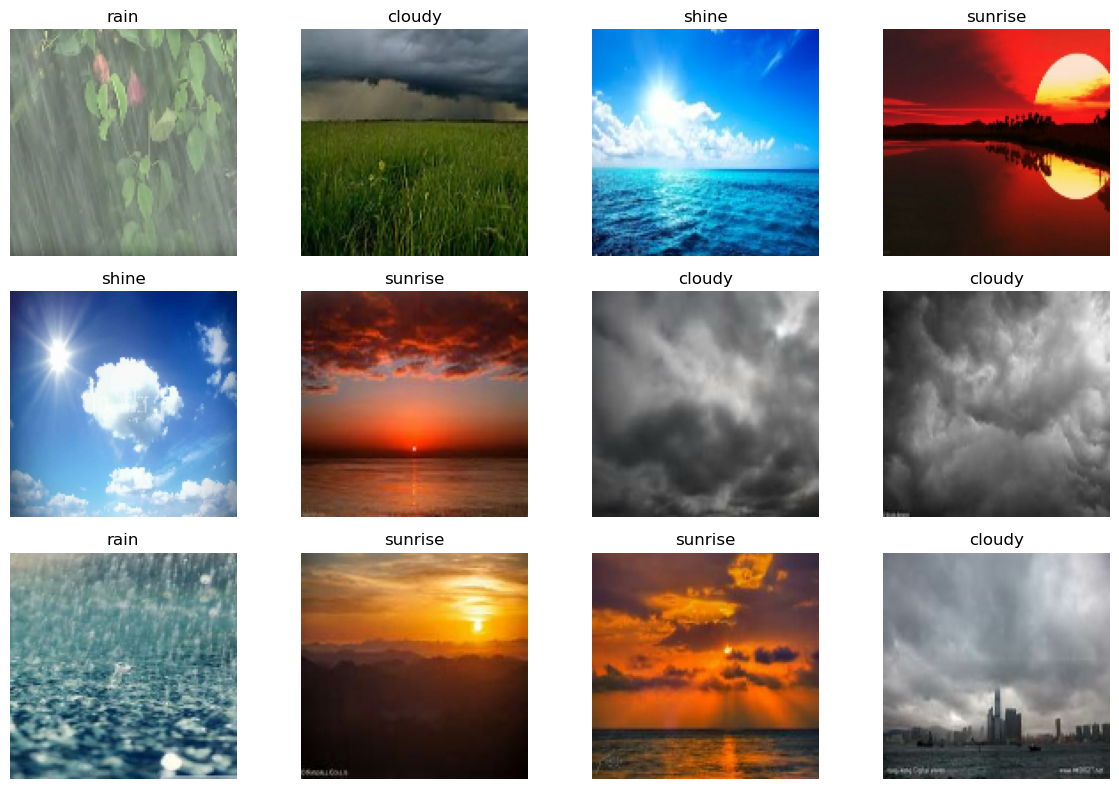

In [13]:
# Visualize a few training samples

plt.figure(figsize=(12, 8))
sample_images, sample_labels = next(iter(train_ds))
for i in range(min(12, len(sample_images))):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(sample_images[i].numpy())
    plt.title(class_names[int(sample_labels[i].numpy())])
    plt.axis("off")
plt.tight_layout()
plt.show()


In [14]:
# CNN model

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
], name="augmentation")

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(*IMG_SIZE, 3)),
    data_augmentation,

    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(256, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(len(class_names), activation="softmax"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,486,212 (9.48 MB)

 Trainable params: 2,486,212 (9.48 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Training

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        mode="max",
        restore_best_weights=True
    )
]

history = model.fit(
    train_ds,
    validation_data=test_ds,   # assignment only asks for a 75/25 split; test set is also used as validation here
    epochs=25,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 181ms/step - accuracy: 0.5356 - loss: 0.9584 - val_accuracy: 0.6370 - val_loss: 0.7688
Epoch 2/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 179ms/step - accuracy: 0.6710 - loss: 0.7875 - val_accuracy: 0.6975 - val_loss: 0.6238
Epoch 3/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 178ms/step - accuracy: 0.6995 - loss: 0.7138 - val_accuracy: 0.8114 - val_loss: 0.5508
Epoch 4/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 201ms/step - accuracy: 0.7898 - loss: 0.5652 - val_accuracy: 0.8434 - val_loss: 0.3901
Epoch 5/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 215ms/step - accuracy: 0.8040 - loss: 0.4894 - val_accuracy: 0.8399 - val_loss: 0.4125
Epoch 6/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 211ms/step - accuracy: 0.8302 - loss: 0.4584 - val_accuracy: 0.8683 - val_loss: 0.3818
Epoch 7/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 212ms/step - accuracy: 0.8539 - loss: 0.3881 - val_accuracy: 0.8185 - val_loss: 0.3915
Epoch 8/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 217ms/step - accuracy: 0.8527 - loss: 0.3935 - val_accuracy: 0.

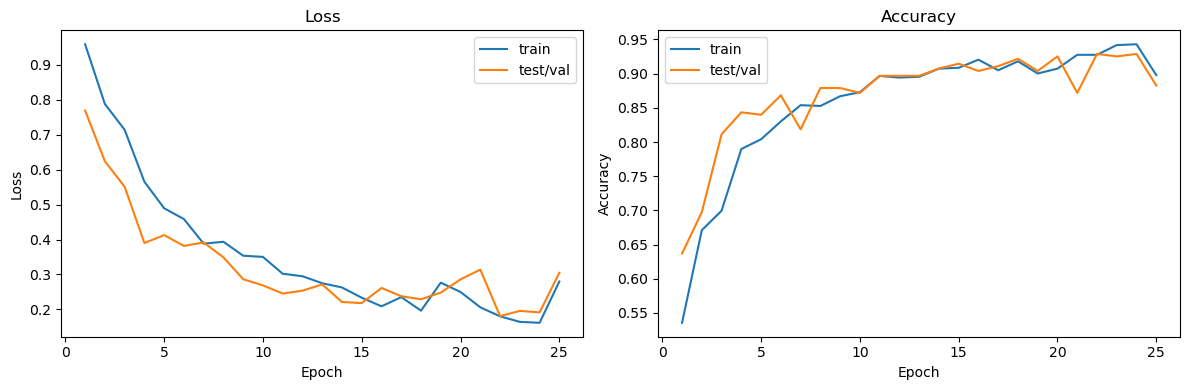

In [16]:
# Learning curves

history_df = pd.DataFrame(history.history)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history_df.index + 1, history_df["loss"], label="train")
ax[0].plot(history_df.index + 1, history_df["val_loss"], label="test/val")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].set_title("Loss")
ax[0].legend()

ax[1].plot(history_df.index + 1, history_df["accuracy"], label="train")
ax[1].plot(history_df.index + 1, history_df["val_accuracy"], label="test/val")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].set_title("Accuracy")
ax[1].legend()

plt.tight_layout()
plt.show()


In [17]:
# Prediction on the held-out 25% test set

y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_prob = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

acc = accuracy_score(y_true, y_pred)
bal_acc = balanced_accuracy_score(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)

print(f"Accuracy          : {acc:.4f}")
print(f"Balanced accuracy : {bal_acc:.4f}")
print(f"Cohen's kappa     : {kappa:.4f}")


Accuracy          : 0.9288
Balanced accuracy : 0.9262
Cohen's kappa     : 0.9041


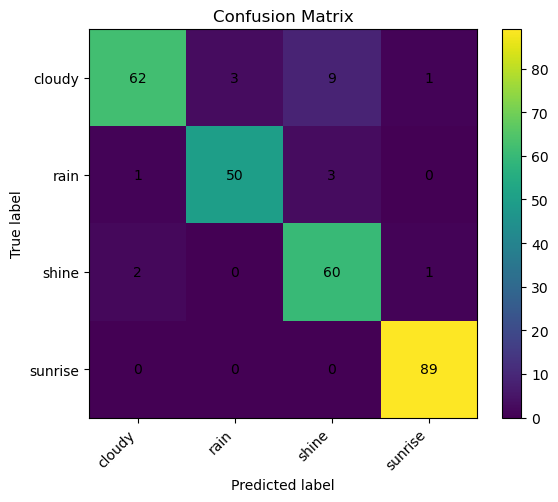

In [18]:
# Confusion matrix

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm)
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(im)
plt.tight_layout()
plt.show()


In [19]:
# Detailed per-class metrics

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
display(report_df)


,precision,recall,f1-score,support
cloudy,0.953846,0.826667,0.885714,75.000000
rain,0.943396,0.925926,0.934579,54.000000
shine,0.833333,0.952381,0.888889,63.000000
sunrise,0.978022,1.000000,0.988889,89.000000
accuracy,0.928826,0.928826,0.928826,0.928826
macro avg,0.927149,0.926243,0.924518,281.000000
weighted avg,0.932476,0.928826,0.928495,281.000000


## Reporting notes

For the written submission, report at least:

- total number of images
- class names and class counts
- train/test split counts
- final test accuracy
- Cohen's kappa
- confusion matrix
- brief comment on the main misclassification pattern

## Methodological caveat

Because the assignment specifies only a **75/25 train-test split**, this notebook uses the held-out 25% subset both for validation during training and for final evaluation. That is acceptable for a coursework-style baseline, but it is **not rigorous** for a publishable workflow. A stronger protocol would use:

- train / validation / test split, or
- k-fold cross-validation, or
- repeated stratified holdout.
